Q1. Dataset Inspection and Cleaning.

To identify input columns and target label, remove duplicates and replace missing numeric values.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('simple_login_activity.csv')

print(df.info())
print('Missing values before cleaning:')
print(df.isna().sum())
print('Duplicate rows:', df.duplicated().sum())

df = df.drop_duplicates().copy()
df['failed_logins'] = df['failed_logins'].fillna(
    df['failed_logins'].median()
)
df['download_mb'] = df['download_mb'].fillna(
    df['download_mb'].median()
)

print('Missing values after cleaning:', df.isna().sum().sum())
print('Duplicate rows after cleaning:', df.duplicated().sum())
print('Final rows:', len(df))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   record_id      101 non-null    int64  
 1   failed_logins  100 non-null    float64
 2   login_hour     101 non-null    int64  
 3   new_device     101 non-null    int64  
 4   download_mb    100 non-null    float64
 5   label          101 non-null    object 
dtypes: float64(2), int64(3), object(1)
memory usage: 4.9+ KB
None
Missing values before cleaning:
record_id        0
failed_logins    1
login_hour       0
new_device       0
download_mb      1
label            0
dtype: int64
Duplicate rows: 1
Missing values after cleaning: 0
Duplicate rows after cleaning: 0
Final rows: 100


Q2. Training and Testing Split.

To separate the features and label and create training and testing sets.

In [2]:
from sklearn.model_selection import train_test_split

features = [
    'failed_logins', 'login_hour',
    'new_device', 'download_mb'
]

X = df[features]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print('Training rows:', len(X_train))
print('Testing rows:', len(X_test))

Training rows: 75
Testing rows: 25


Q3. Decision Tree Training and Evaluation.

To train a Decision Tree and interpret accuracy and the confusion matrix.

Accuracy: 88.00%


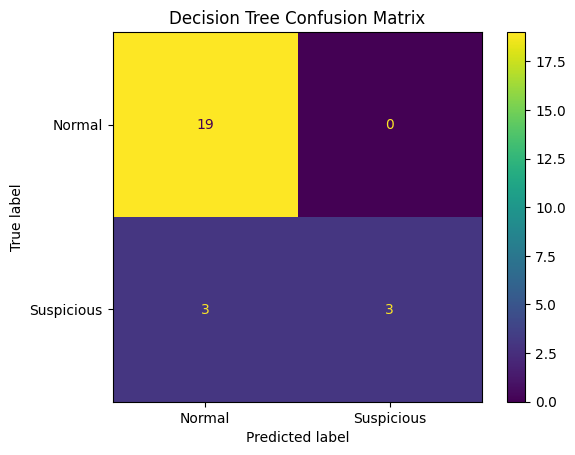

In [3]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    ConfusionMatrixDisplay
)

model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f'Accuracy: {accuracy * 100:.2f}%')

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=['Normal', 'Suspicious']
)
plt.title('Decision Tree Confusion Matrix')
plt.show()

Q4. K-Means Clustering

To apply an unsupervised method and compare clusters with the known labels.

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)
df['cluster'] = kmeans.fit_predict(X_scaled)

cluster_summary = df.groupby('cluster')[features].mean().round(2)
label_summary = pd.crosstab(df['cluster'], df['label'])

display(cluster_summary)
display(label_summary)

,failed_logins,login_hour,new_device,download_mb
cluster,,,,
0,2.00,12.81,1.0,192.69
1,2.16,11.63,0.0,236.15


label,Normal,Suspicious
cluster,,
0,24,13
1,51,12


Q5. Feature Importance and New Record Prediction

To identify the features used most by the tree and predict three new login records.

,feature,importance
1,login_hour,0.413391
0,failed_logins,0.392826
3,download_mb,0.193783
2,new_device,0.000000


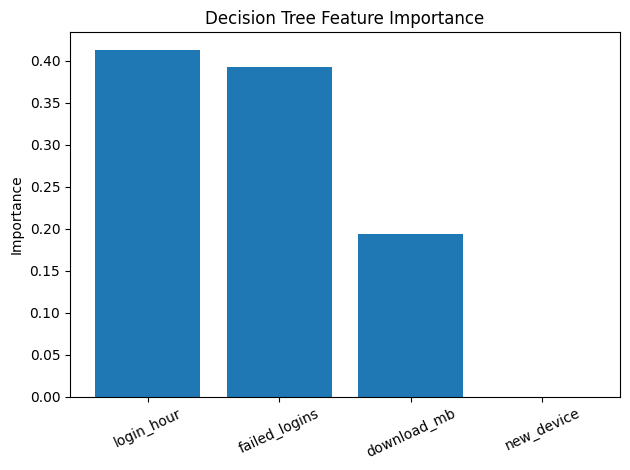

,failed_logins,login_hour,new_device,download_mb,prediction
0,0,10,0,45,Normal
1,8,2,1,180,Suspicious
2,2,23,1,900,Suspicious


In [5]:
importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

display(importance)

plt.bar(importance['feature'], importance['importance'])
plt.title('Decision Tree Feature Importance')
plt.ylabel('Importance')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

new_records = pd.DataFrame([
    {'failed_logins': 0, 'login_hour': 10,
     'new_device': 0, 'download_mb': 45},
    {'failed_logins': 8, 'login_hour': 2,
     'new_device': 1, 'download_mb': 180},
    {'failed_logins': 2, 'login_hour': 23,
     'new_device': 1, 'download_mb': 900}
])

new_records['prediction'] = model.predict(new_records)
display(new_records)

Q6. False Positives, False Negatives and Reflection.

To explain two important model errors and summarize the suitability of the model.

In [6]:
print(
    'False positive example:',
    'Legitimate late-night work on a new device is marked Suspicious.'
)
print(
    'False negative example:',
    'A disguised attack with few obvious indicators is marked Normal.'
)

df.to_csv('Lab2_Login_ML_Result.csv', index=False)
print('Saved: Lab2_Login_ML_Result.csv')

False positive example: Legitimate late-night work on a new device is marked Suspicious.
False negative example: A disguised attack with few obvious indicators is marked Normal.
Saved: Lab2_Login_ML_Result.csv
